In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/heart-rate-signal/ptbdb_abnormal.csv
/kaggle/input/heart-rate-signal/ptbdb_normal.csv


In [2]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import random
import copy
import warnings

warnings.filterwarnings('ignore')

# CONFIGURATION

CONFIG = {
    'SEED': 42,
    'BATCH_SIZE': 64,
    'EPOCHS': 50,
    'LR': 1e-3,
    'HIDDEN_DIM': 128,
    'MAX_LEN': 187,   
    'THRESHOLD': 0.05 
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Running on Device: {device}")

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(CONFIG['SEED'])

Running on Device: cuda


In [3]:
#  PREPROCESSING FUNCTIONS

def remove_padding(signals, threshold=0.05):
    """
    Trims trailing zeros
    """
    cleaned = []
    for sig in signals:
        non_zero_idx = np.where(np.abs(sig) > threshold)[0]
        if len(non_zero_idx) > 0:
            cleaned.append(sig[:non_zero_idx[-1] + 1])
        else:
            cleaned.append(sig[:10]) 
    return cleaned

def scale_signals(signals, mean, std):
    """
    Standardizes a list of signals 
    """
    std = std + 1e-8
    return [(sig - mean) / std for sig in signals]


In [4]:
#  DATA LOADING

print("Loading PTBDB dataset...")

try:
    normal_df = pd.read_csv('/kaggle/input/heart-rate-signal/ptbdb_normal.csv', header=None)
    abnormal_df = pd.read_csv('/kaggle/input/heart-rate-signal/ptbdb_abnormal.csv', header=None)
except FileNotFoundError:
    print("Not found!")

normal_df.iloc[:, -1] = 0
abnormal_df.iloc[:, -1] = 1

data_df = pd.concat([normal_df, abnormal_df], ignore_index=True)
X_raw_numpy = data_df.iloc[:, :-1].values.astype(np.float32)
y_all = data_df.iloc[:, -1].values.astype(np.int64)

print("Removing padding...")
X_cleaned_list = remove_padding(X_raw_numpy, threshold=CONFIG['THRESHOLD'])

# Split: Train/Val (85%) and Hold-out Test (15%)
indices = np.arange(len(y_all))
X_train_val, X_holdout, y_train_val, y_holdout, idx_train_val, idx_holdout = train_test_split(
    X_cleaned_list, y_all, indices, test_size=0.15, stratify=y_all, random_state=CONFIG['SEED']
)

print(f"Train/Val size: {len(X_train_val)} | Hold-out Test size: {len(X_holdout)}")

Loading PTBDB dataset...
Removing padding...
Train/Val size: 12369 | Hold-out Test size: 2183


In [5]:
# DATASET & MODEL

class ECGDataset(Dataset):
    def __init__(self, signals, labels, max_len=187):
        self.signals = signals
        self.labels = labels
        self.max_len = max_len

    def __len__(self):
        return len(self.signals)

    def __getitem__(self, idx):
        sig = self.signals[idx]
        
        if len(sig) > self.max_len:
            sig = sig[:self.max_len]
            
        real_len = len(sig)
        
    
        pad_amount = self.max_len - real_len
        if pad_amount > 0:
            sig = np.pad(sig, (0, pad_amount), 'constant', constant_values=0)
            
        return (torch.tensor(sig, dtype=torch.float32), 
                torch.tensor(self.labels[idx], dtype=torch.long), 
                torch.tensor(real_len, dtype=torch.long))

def collate_fn(batch):
    """Stacks batch elements."""
    sigs, labels, lens = zip(*batch)
    return torch.stack(sigs), torch.stack(labels), torch.stack(lens)

class BiLSTMAttention(nn.Module):
    def __init__(self, input_size=1, hidden_dim=128, num_layers=2, dropout=0.3):
        super(BiLSTMAttention, self).__init__()
        
        self.hidden_dim = hidden_dim
        
        # BiLSTM
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            bidirectional=True,
            batch_first=True,
            dropout=dropout
        )
        
        # Attention Components
        self.attn_weight = nn.Linear(hidden_dim * 2, 1)
        
        # Output components
        self.layer_norm = nn.LayerNorm(hidden_dim * 2)
        self.gelu = nn.GELU()
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, 2)

    def attention_net(self, lstm_output, lengths):
        
        # attention scores
        attn_scores = self.attn_weight(lstm_output).squeeze(-1) 
        
        # Masking
        mask = (torch.arange(lstm_output.size(1), device=lstm_output.device)[None, :] < lengths[:, None])
        
        attn_scores = attn_scores.masked_fill(~mask, -1e9)
        
        # Softmax to get probabilities
        attn_probs = torch.nn.functional.softmax(attn_scores, dim=1)
        
        context = torch.bmm(attn_probs.unsqueeze(1), lstm_output).squeeze(1)
        return context, attn_probs

    def forward(self, x, lengths):
        x = x.unsqueeze(-1)
        
        # Pack 
        packed_input = nn.utils.rnn.pack_padded_sequence(x, lengths.cpu(), batch_first=True, enforce_sorted=False)
        
        packed_output, _ = self.lstm(packed_input)
        
        # Unpack
        lstm_out, _ = nn.utils.rnn.pad_packed_sequence(packed_output, batch_first=True)
        
        # Attention
        context_vector, _ = self.attention_net(lstm_out, lengths)
        
        # Classifier
        out = self.layer_norm(context_vector)
        out = self.gelu(out)
        out = self.dropout(out)
        out = self.fc(out)
        return out

In [6]:
# TRAINING 

def train_fold_logic(X_train_raw, y_train, X_val_raw, y_val, fold_idx):
    """
    Trains a model for one fold with DETAILED LOGGING per epoch.
    """
    
    # Scaling Statistics
    flat_train = np.concatenate(X_train_raw)
    mu = flat_train.mean()
    std = flat_train.std()
    
    #Apply Scaling
    X_train_scaled = scale_signals(X_train_raw, mu, std)
    X_val_scaled = scale_signals(X_val_raw, mu, std)
    
    #Create Loaders
    train_ds = ECGDataset(X_train_scaled, y_train, max_len=CONFIG['MAX_LEN'])
    val_ds = ECGDataset(X_val_scaled, y_val, max_len=CONFIG['MAX_LEN'])
    
    train_loader = DataLoader(train_ds, batch_size=CONFIG['BATCH_SIZE'], shuffle=True, collate_fn=collate_fn)
    val_loader = DataLoader(val_ds, batch_size=CONFIG['BATCH_SIZE'], shuffle=False, collate_fn=collate_fn)
    
    # Class Weights
    counts = np.bincount(y_train)
    weights = torch.tensor([len(y_train)/(2*c) for c in counts], dtype=torch.float32).to(device)
    
    #Model Setup
    model = BiLSTMAttention(hidden_dim=CONFIG['HIDDEN_DIM']).to(device)
    criterion = nn.CrossEntropyLoss(weight=weights)
    optimizer = optim.AdamW(model.parameters(), lr=CONFIG['LR'], weight_decay=1e-2)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)
    
    best_f1 = 0
    patience_counter = 0
    patience_limit = 7
    best_state = None
    
    print(f"\n--- Fold {fold_idx} Training Started ---")
    
    #Training Loop
    for epoch in range(CONFIG['EPOCHS']):
        model.train()
        train_loss_sum = 0
        train_preds_all = []
        train_labels_all = []
        
        for sigs, labels, lens in train_loader:
            sigs, labels, lens = sigs.to(device), labels.to(device), lens.to(device)
            
            optimizer.zero_grad()
            outputs = model(sigs, lens)
            loss = criterion(outputs, labels)
            loss.backward()
            
            # Gradient Clipping
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            
            train_loss_sum += loss.item()
            
            # Collect for metrics
            preds = torch.argmax(outputs, dim=1)
            train_preds_all.extend(preds.cpu().numpy())
            train_labels_all.extend(labels.cpu().numpy())
            
        avg_train_loss = train_loss_sum / len(train_loader)
        train_f1 = f1_score(train_labels_all, train_preds_all, average='macro')

        #VALIDATION
        model.eval()
        val_loss_sum = 0
        val_preds_all = []
        val_labels_all = []
        
        with torch.no_grad():
            for sigs, labels, lens in val_loader:
                sigs, labels, lens = sigs.to(device), labels.to(device), lens.to(device)
                
                outputs = model(sigs, lens)
                v_loss = criterion(outputs, labels)
                val_loss_sum += v_loss.item()
                
                preds = torch.argmax(outputs, dim=1)
                val_preds_all.extend(preds.cpu().numpy())
                val_labels_all.extend(labels.cpu().numpy())
                
        avg_val_loss = val_loss_sum / len(val_loader)
        val_f1 = f1_score(val_labels_all, val_preds_all, average='macro')
        
        
        print(f"Fold {fold_idx} | Epoch {epoch+1:02d}/{CONFIG['EPOCHS']} | "
              f"Train Loss: {avg_train_loss:.4f} | Train F1: {train_f1:.4f} | "
              f"Val Loss: {avg_val_loss:.4f} | Val F1: {val_f1:.4f}")

        # Scheduler Step
        scheduler.step(val_f1)
        
        # Checkpointing
        if val_f1 > best_f1:
            best_f1 = val_f1
            best_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
            print(f"    >>> New Best Score! (Saved)")
        else:
            patience_counter += 1
            if patience_counter >= patience_limit:
                print(f"    [Early Stopping] No improvement for {patience_limit} epochs.")
                break
                
    return best_f1, best_state, (mu, std)



In [7]:
# MAIN EXECUTION 

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=CONFIG['SEED'])

fold_results = []
best_overall_f1 = 0
best_model_info = {} 

print("\n" + "="*60)
print(" STARTING 5-FOLD CROSS VALIDATION WITH DETAILED LOGS")
print("="*60)

dummy_X = np.zeros(len(y_train_val))

for fold_idx, (train_idx, val_idx) in enumerate(skf.split(dummy_X, y_train_val)):
    # Data Splitting
    X_tr_fold = [X_train_val[i] for i in train_idx]
    y_tr_fold = y_train_val[train_idx]
    
    X_val_fold = [X_train_val[i] for i in val_idx]
    y_val_fold = y_train_val[val_idx]
    
    # Train (Now with detailed prints inside)
    f1, state, stats = train_fold_logic(X_tr_fold, y_tr_fold, X_val_fold, y_val_fold, fold_idx+1)
    
    print(f"\n*** Fold {fold_idx+1} Completed. Best Val F1: {f1:.4f} ***\n")
    fold_results.append(f1)
    
    if f1 > best_overall_f1:
        best_overall_f1 = f1
        best_model_info = {
            'state_dict': state,
            'mu': stats[0],
            'std': stats[1],
            'fold': fold_idx+1
        }

print("\n" + "-"*40)
print(f"CV Average F1: {np.mean(fold_results):.4f} (+/- {np.std(fold_results):.4f})")
print("-"*40)



 STARTING 5-FOLD CROSS VALIDATION WITH DETAILED LOGS

--- Fold 1 Training Started ---
Fold 1 | Epoch 01/50 | Train Loss: 0.6459 | Train F1: 0.5180 | Val Loss: 0.5979 | Val F1: 0.5852
    >>> New Best Score! (Saved)
Fold 1 | Epoch 02/50 | Train Loss: 0.5834 | Train F1: 0.5991 | Val Loss: 0.5524 | Val F1: 0.6600
    >>> New Best Score! (Saved)
Fold 1 | Epoch 03/50 | Train Loss: 0.5306 | Train F1: 0.6679 | Val Loss: 0.4648 | Val F1: 0.7194
    >>> New Best Score! (Saved)
Fold 1 | Epoch 04/50 | Train Loss: 0.4400 | Train F1: 0.7617 | Val Loss: 0.3559 | Val F1: 0.8222
    >>> New Best Score! (Saved)
Fold 1 | Epoch 05/50 | Train Loss: 0.3277 | Train F1: 0.8409 | Val Loss: 0.2553 | Val F1: 0.8804
    >>> New Best Score! (Saved)
Fold 1 | Epoch 06/50 | Train Loss: 0.2639 | Train F1: 0.8788 | Val Loss: 0.2567 | Val F1: 0.8718
Fold 1 | Epoch 07/50 | Train Loss: 0.2307 | Train F1: 0.8926 | Val Loss: 0.2060 | Val F1: 0.9208
    >>> New Best Score! (Saved)
Fold 1 | Epoch 08/50 | Train Loss: 0.1940 


 FINAL TEST on HOLD-OUT SET (Using Best Fold #3)
              precision    recall  f1-score   support

      Normal     0.9770    0.9819    0.9795       607
    Abnormal     0.9930    0.9911    0.9921      1576

    accuracy                         0.9885      2183
   macro avg     0.9850    0.9865    0.9858      2183
weighted avg     0.9886    0.9885    0.9886      2183



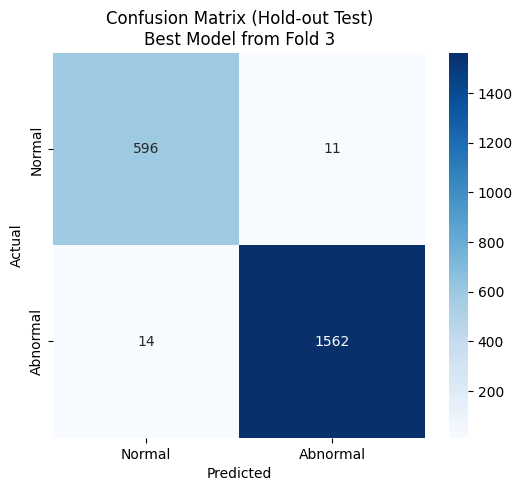

In [8]:
# EVALUATION 

print("\n" + "="*40)
print(f" FINAL TEST on HOLD-OUT SET (Using Best Fold #{best_model_info['fold']})")
print("="*40)

#  Load the Best Model
final_model = BiLSTMAttention(hidden_dim=CONFIG['HIDDEN_DIM']).to(device)
final_model.load_state_dict(best_model_info['state_dict'])
final_model.eval()

mu_final = best_model_info['mu']
std_final = best_model_info['std']

X_holdout_scaled = scale_signals(X_holdout, mu_final, std_final)

# Create Loader
test_ds = ECGDataset(X_holdout_scaled, y_holdout, max_len=CONFIG['MAX_LEN'])
test_loader = DataLoader(test_ds, batch_size=CONFIG['BATCH_SIZE'], shuffle=False, collate_fn=collate_fn)

#Inference
y_true_final = []
y_pred_final = []
y_prob_final = []

with torch.no_grad():
    for sigs, labels, lens in test_loader:
        sigs, lens = sigs.to(device), lens.to(device)
        outputs = final_model(sigs, lens)
        
        probs = torch.softmax(outputs, dim=1)[:, 1] 
        preds = torch.argmax(outputs, dim=1)
        
        y_true_final.extend(labels.numpy())
        y_pred_final.extend(preds.cpu().numpy())
        y_prob_final.extend(probs.cpu().numpy())

#Metrics
print(classification_report(y_true_final, y_pred_final, target_names=['Normal', 'Abnormal'], digits=4))

cm = confusion_matrix(y_true_final, y_pred_final)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Normal', 'Abnormal'], 
            yticklabels=['Normal', 'Abnormal'])
plt.title(f"Confusion Matrix (Hold-out Test)\nBest Model from Fold {best_model_info['fold']}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [9]:
#SAVING THE BEST MODEL

print("\n" + "="*40)
print(" SAVING BEST MODEL")
print("="*40)

save_path = 'best_ecg_model_complete.pth'
checkpoint = {
    'model_state_dict': best_model_info['state_dict'],
    'mu': best_model_info['mu'],
    'std': best_model_info['std'],
    'config': CONFIG,
    'best_f1_score': best_overall_f1,
    'best_fold_index': best_model_info['fold']
}

torch.save(checkpoint, save_path)
print(f"Model successfully saved to: {save_path}")
print(f"Contains weights, mu={best_model_info['mu']:.4f}, std={best_model_info['std']:.4f}")
print("Use this file for future inference.")


 SAVING BEST MODEL
Model successfully saved to: best_ecg_model_complete.pth
Contains weights, mu=0.2774, std=0.2132
Use this file for future inference.
